In [ ]:
# CCTV Detection using Machine Learning

This project detects objects/persons from CCTV footage using ML models.

In [ ]:
!pip install ultralytics deepface opencv-python-headless yagmail

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving WhatsApp Image 2026-04-14 at 1.07.20 PM.jpeg to WhatsApp Image 2026-04-14 at 1.07.20 PM (1).jpeg


🚀 System Started...
📸 Capturing image...


<IPython.core.display.Javascript object>

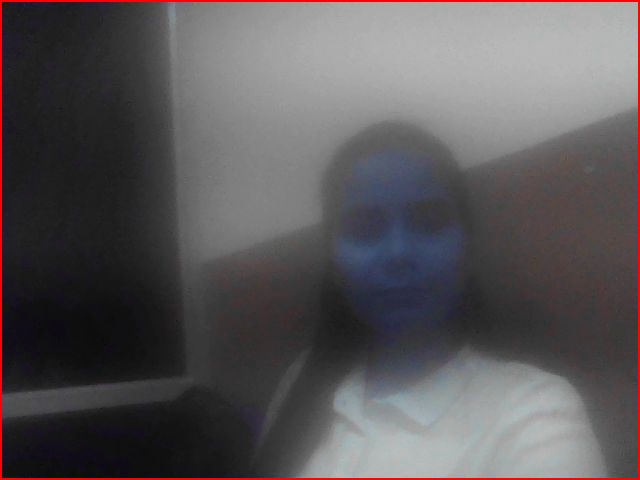

🚨 Stranger Found! Sending Email...
📧 Email Sent!


In [ ]:
import cv2
import numpy as np
from deepface import DeepFace
import yagmail

# Colab camera
from IPython.display import display, Javascript
from google.colab.output import eval_js
import base64
from PIL import Image
import io

# -----------------------
# CAMERA FUNCTION (Mobile Friendly)
# -----------------------
def take_photo():
    js = Javascript('''
        async function takePhoto() {
          const div = document.createElement('div');
          const video = document.createElement('video');
          video.style.display = 'block';
          const stream = await navigator.mediaDevices.getUserMedia({video: true});

          document.body.appendChild(div);
          div.appendChild(video);
          video.srcObject = stream;
          await video.play();

          await new Promise(resolve => setTimeout(resolve, 3000));

          const canvas = document.createElement('canvas');
          canvas.width = video.videoWidth;
          canvas.height = video.videoHeight;
          canvas.getContext('2d').drawImage(video, 0, 0);

          stream.getTracks().forEach(track => track.stop());
          div.remove();

          return canvas.toDataURL('image/jpeg', 0.8);
        }
        takePhoto();
    ''')
    display(js)
    data = eval_js('takePhoto()')
    binary = base64.b64decode(data.split(',')[1])
    return Image.open(io.BytesIO(binary))

# -----------------------
# CONFIG
# -----------------------
KNOWN_IMAGE = "/content/WhatsApp Image 2026-04-14 at 1.07.20 PM (1).jpeg"

EMAIL = "lily.atoz123@gmail.com"
APP_PASSWORD = "fbkd pnio prlb tvyy"
RECEIVER = "codeinyourself@gmail.com"

yag = yagmail.SMTP("lily.atoz123@gmail.com", "fbkd pnio prlb tvyy")

print("🚀 System Started...")

# -----------------------
# LOOP
# -----------------------
while True:
    print("📸 Capturing image...")

    img_pil = take_photo()
    frame = np.array(img_pil)

    stranger_found = False

    try:
        # Detect ALL faces
        detections = DeepFace.extract_faces(frame, enforce_detection=False)

        if len(detections) == 0:
            print("⚠️ No face detected")

        for face_obj in detections:
            face = face_obj["face"]

            try:
                result = DeepFace.verify(face, KNOWN_IMAGE, enforce_detection=False)

                if result["verified"]:
                    label = "Known"
                    color = (0, 255, 0)
                else:
                    label = "Stranger"
                    color = (0, 0, 255)
                    stranger_found = True

                # Draw box
                x = face_obj["facial_area"]["x"]
                y = face_obj["facial_area"]["y"]
                w = face_obj["facial_area"]["w"]
                h = face_obj["facial_area"]["h"]

                cv2.rectangle(frame, (x, y), (x+w, y+h), color, 2)
                cv2.putText(frame, label, (x, y-10),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.9, color, 2)

            except:
                print("⚠️ Face comparison failed")

        # Show result image
        from google.colab.patches import cv2_imshow
        cv2_imshow(frame)

        # -----------------------
        # EMAIL ALERT
        # -----------------------
        if stranger_found:
            print("🚨 Stranger Found! Sending Email...")

            cv2.imwrite("alert.jpg", frame)

            yag.send(
                to=RECEIVER,
                subject="🚨 ALERT: Stranger Detected!",
                contents="Unknown person detected in your room.",
                attachments="alert.jpg"
            )

            print("📧 Email Sent!")

        else:
            print("✅ All persons are known")

    except Exception as e:
        print("⚠️ Error:", e)

    choice = input("Press ENTER to continue or type 'q' to quit: ")
    if choice.lower() == 'q':
        break